# Citation Network Analysis with Author Influence
Fariha Adil, 2375026

## About
The goal of this analysis is to build a citation network to identify influential papers and authors. Graph-based metrics like PageRank and in-degree centrality are used to measure influence, which is then tracked over time to reveal how impact evolves and which papers represent true breakthroughs in computer science research.

## Tasks
- Build a directed citation network where nodes are papers and edges represent citation relationships
- Use graph metrics (in-degree centrality and PageRank) to identify influential papers and authors
- Combine influence scores with temporal data to track how author and paper impact evolves over time
- Identify breakthrough papers that shifted research directions using citation velocity and PageRank

## Motivations
- Understand which papers and authors have truly shaped computer science research beyond simple citation counts
- Identify emerging researchers and paradigm-shifting work that may go unnoticed by raw citation metrics alone
- Track how influence evolves: does an author's impact grow over time or fade? Do seminal papers maintain relevance?
- Discover research momentum: which areas are gaining traction vs. declining

## Challenges
- Computational complexity: building and analyzing networks with millions of nodes and edges requires efficient graph algorithms and working with filtered subsets
- Incomplete citation data: not all papers cite all prior relevant work; citations reflect only the subset recorded in DBLP
- Temporal dynamics: influence changes over time; time windows must be carefully defined and papers with delayed impact must be accounted for
- Bias in metrics: PageRank and centrality favor well-established papers; must balance with novelty metrics like citation velocity
- Author disambiguation: the same name can refer to different authors, making author-level influence aggregation imprecise

In [145]:
"""Import Dependencies"""
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import os
from collections import defaultdict

In [146]:
"""Globals/Constants"""
START_YEAR = 2000
END_YEAR = 2017

In [147]:
"""Load Data"""
cleaned = pd.read_pickle('cleaned_dataset.pkl')

In [148]:
"""Sample for Graph Analysis"""
sample = cleaned.copy()
print(f"Working sample size: {len(sample):,}")

Working sample size: 3,079,003


In [149]:
"""Build Citation Network"""
paper_ids = set(sample['id'])

citation_graph = nx.DiGraph()
citation_graph.add_nodes_from(sample['id'])

for paper in sample.itertuples():
    for ref_id in paper.references:
        if ref_id in paper_ids:
            citation_graph.add_edge(paper.id, ref_id)

print(f"Nodes: {citation_graph.number_of_nodes():,}")
print(f"Edges: {citation_graph.number_of_edges():,}")
print(f"Is DAG: {nx.is_directed_acyclic_graph(citation_graph)}")

Nodes: 3,079,003
Edges: 25,166,984
Is DAG: False


In [150]:
"""Graph Metrics: In-Degree Centrality and PageRank"""
in_degree = dict(citation_graph.in_degree())
pagerank = nx.pagerank(citation_graph, alpha = 0.85)
id_to_info = sample.set_index('id')[['title', 'year', 'venue', 'n_citation']].to_dict('index')

rows = []
for paper_id, pr_score in pagerank.items():
    info = id_to_info.get(paper_id, {})
    rows.append(
        {'id': paper_id, 
         'title': info.get('title', ''), 
         'year': info.get('year', ''), 
         'venue': info.get('venue', ''), 
         'n_citation': info.get('n_citation', 0), 
         'in_degree': in_degree.get(paper_id, 0), 
         'pagerank': pr_score}
    )

metrics_df = pd.DataFrame(rows)
top_papers = metrics_df.sort_values('pagerank', ascending = False).head(20).reset_index(drop = True)
top_papers

,id,title,year,venue,n_citation,in_degree,pagerank
0,6a6b9aa6-683f-4c7c-b06e-9c3018d10fd3,"Genetic Algorithms in Search, Optimization and...",1989,,73362,13267,0.000623
1,c1b6b493-01ef-420f-be44-7bacfe34e846,LIBSVM: A library for support vector machines,2011,ACM Transactions on Intelligent Systems and Te...,33016,13475,0.000338
2,b944f77f-113b-4a02-ae5e-d4a124b8fd5b,Distinctive Image Features from Scale-Invarian...,2004,International Journal of Computer Vision,42508,16229,0.000329
3,d3e00e7e-1c64-4d7a-b2b2-1ad98ba4c706,Probabilistic Reasoning in Intelligent Systems...,1988,,6589,6589,0.000221
4,f6bd8b64-684d-429a-aab5-8ff3a2c23cd6,Random Forests,2001,Machine Learning,28679,7968,0.000220
5,65d5ccdc-7022-45b0-adf9-0385273b1283,A fast and elitist multiobjective genetic algo...,2002,IEEE Transactions on Evolutionary Computation,24245,6696,0.000205
6,62549bc2-e0b3-46e8-8d32-390dded105d5,C4.5: Programs for Machine Learning,1993,,6906,6906,0.000202
7,2659531e-eb9d-4dd5-b46f-10f66a4819c6,A simple transmit diversity technique for wire...,1998,IEEE Journal on Selected Areas in Communications,16490,5063,0.000192
8,1c63e1d5-b963-455b-829d-e4f3eb63a36a,Snakes: Active Contour Models,1988,International Journal of Computer Vision,21256,5973,0.000192
9,e0f3a738-4ab2-40d1-ba44-506d81c1d230,Reinforcement Learning: An Introduction,1999,neural information processing systems,29285,5483,0.000187


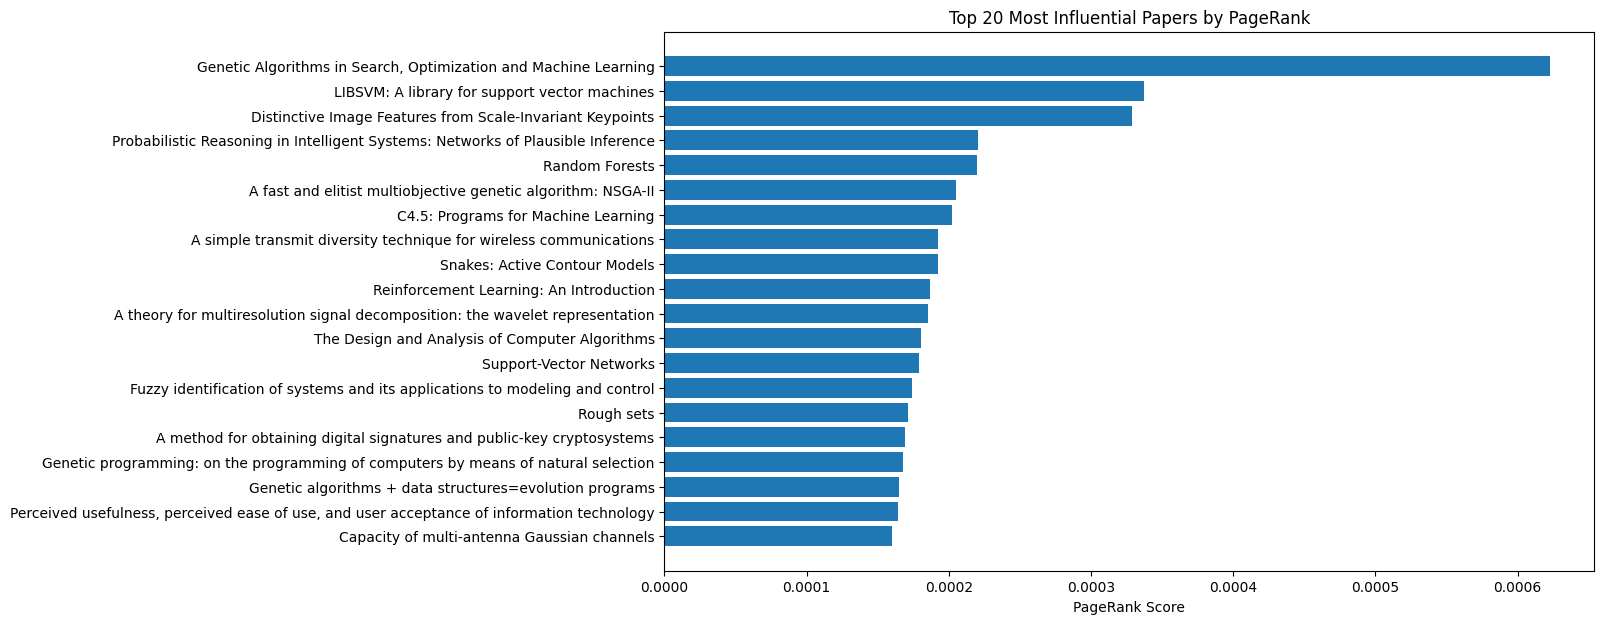

In [151]:
"""Plot Top Papers by Pagerank"""
plt.figure(figsize = (12, 7))
plt.barh(top_papers['title'][::-1], top_papers['pagerank'][::-1])
plt.xlabel('PageRank Score')
plt.title('Top 20 Most Influential Papers by PageRank')
plt.savefig('figures/Top Papers by PageRank.png', bbox_inches = 'tight')
plt.show()

In [152]:
"""Aggregating Influence by Author"""
author_scores = defaultdict(float)
author_paper_count = defaultdict(int)

for paper in sample.itertuples():
    pr = pagerank.get(paper.id, 0)
    for author in paper.authors:
        if author:
            author_scores[author] += pr
            author_paper_count[author] += 1

author_df = pd.DataFrame(
    [{'author': author, 
      'total_pagerank': score, 
      'paper_count': author_paper_count[author], 
      'avg_pagerank': score / author_paper_count[author]} 
      for author, score in author_scores.items()
    ]
)
top_authors = author_df.sort_values('total_pagerank', ascending = False).head(20).reset_index(drop = True)
top_authors

,author,total_pagerank,paper_count,avg_pagerank
0,anil k. jain,0.001019,546,1.866497e-06
1,david e. goldberg,0.000931,238,3.913491e-06
2,hari balakrishnan,0.000865,181,4.780633e-06
3,scott shenker,0.000809,267,3.029944e-06
4,ian t. foster,0.000768,406,1.891932e-06
5,rakesh agrawal,0.000723,200,3.616301e-06
6,jiawei han,0.000720,737,9.762977e-07
7,ian f. akyildiz,0.000691,371,1.861783e-06
8,david e. culler,0.000662,210,3.151959e-06
9,wei wang,0.000631,2518,2.507223e-07


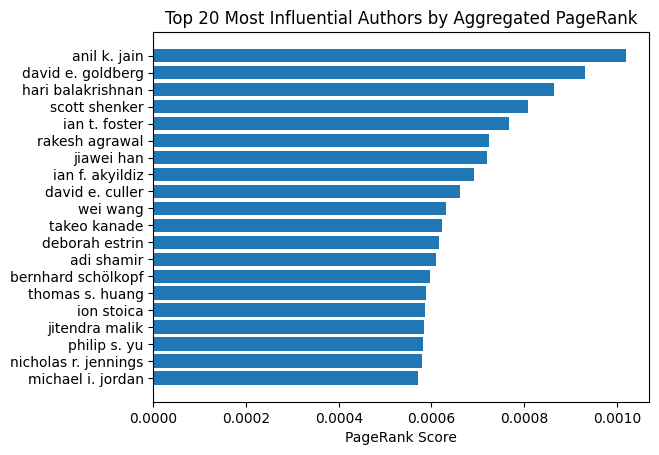

In [153]:
"""Plot Top Authors by Influence"""
plt.barh(top_authors['author'][::-1], top_authors['total_pagerank'][::-1])
plt.xlabel('PageRank Score')
plt.title('Top 20 Most Influential Authors by Aggregated PageRank')
plt.savefig('figures/Top Authors by Influence.png', bbox_inches = 'tight')
plt.show()

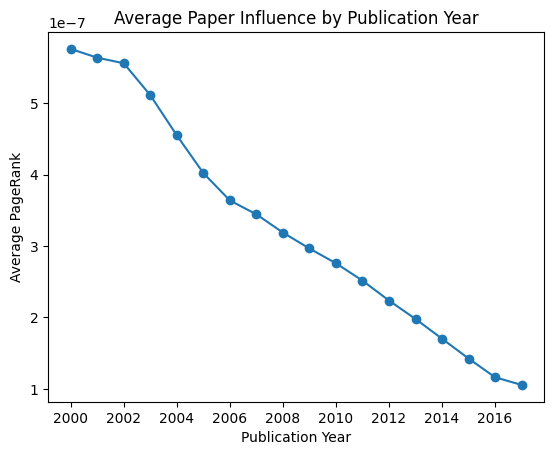

In [154]:
"""Temporal Analysis: Influence by Publication Year"""
yearly_pagerank = (metrics_df.groupby('year')['pagerank'].mean().reset_index().rename(columns = {'pagerank': 'avg_pagerank'}))
yearly_pagerank = yearly_pagerank[(yearly_pagerank['year'] >= START_YEAR) & (yearly_pagerank['year'] <= END_YEAR)]

plt.plot(yearly_pagerank['year'], yearly_pagerank['avg_pagerank'], marker = 'o')
plt.xlabel('Publication Year')
plt.ylabel('Average PageRank')
plt.title('Average Paper Influence by Publication Year')
plt.xticks(range(START_YEAR, END_YEAR + 1, 2))
plt.savefig('figures/Average Influence by Publication Year.png', bbox_inches = 'tight')
plt.show()

In [155]:
"""Identify Breakthrough Papers"""
metrics_df['years_since_pub'] = 2018 - metrics_df['year']
metrics_df['citation_velocity'] = metrics_df.apply(lambda row: row['n_citation'] / row['years_since_pub'] if row['years_since_pub'] > 0 else 0, axis = 1)

pr_threshold = metrics_df['pagerank'].quantile(0.9)
cv_threshold = metrics_df['citation_velocity'].quantile(0.9)

breakthrough = metrics_df[(metrics_df['pagerank'] >= pr_threshold) & (metrics_df['citation_velocity'] >= cv_threshold)].sort_values('citation_velocity', ascending = False).head(15).reset_index(drop = True)
breakthrough[['title', 'year', 'venue', 'n_citation', 'citation_velocity', 'pagerank']]

,title,year,venue,n_citation,citation_velocity,pagerank
0,LIBSVM: A library for support vector machines,2011,ACM Transactions on Intelligent Systems and Te...,33016,4716.571429,0.000338
1,ImageNet Classification with Deep Convolutiona...,2012,neural information processing systems,22884,3814.000000,0.000079
2,Faster R-CNN: Towards Real-Time Object Detecti...,2017,IEEE Transactions on Pattern Analysis and Mach...,3786,3786.000000,0.000007
3,Distinctive Image Features from Scale-Invarian...,2004,International Journal of Computer Vision,42508,3036.285714,0.000329
4,"Genetic Algorithms in Search, Optimization and...",1989,,73362,2529.724138,0.000623
5,Deep learning,2015,Nature,7273,2424.333333,0.000019
6,Speeded-Up Robust Features (SURF),2008,Computer Vision and Image Understanding,19684,1968.400000,0.000063
7,Bowling alone: the collapse and revival of Ame...,2000,conference on computer supported cooperative work,34288,1904.888889,0.000043
8,Clustal W and Clustal X version 2.0,2007,Bioinformatics,20580,1870.909091,0.000015
9,Caffe: Convolutional Architecture for Fast Fea...,2014,acm multimedia,7464,1866.000000,0.000032


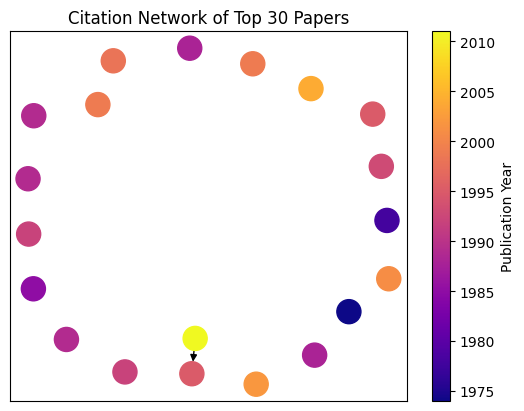

In [ ]:
"""Visualize Citation Network of Top 30 Papers"""
top_ids = set(top_papers['id'].head(30))
subgraph = citation_graph.subgraph(top_ids)

year_map = sample.set_index('id')['year'].to_dict()
node_years = [year_map.get(node, START_YEAR) for node in subgraph.nodes()]

pos = nx.spring_layout(subgraph, seed = 42)
nx.draw_networkx_edges(subgraph, pos, arrows = True)
sc = nx.draw_networkx_nodes(subgraph, pos, node_color = node_years, cmap = plt.cm.plasma)
plt.colorbar(sc, label = 'Publication Year')
plt.title('Citation Network of Top 30 Papers')
plt.savefig('figures/Citation Network of Top 30 Papers.png', bbox_inches = 'tight')
plt.show()


In [157]:
"""Save Outputs"""
os.makedirs('outputs', exist_ok = True)
top_papers.to_csv('outputs/top_papers_by_pagerank.csv', index = False)
top_authors.to_csv('outputs/top_authors_by_influence.csv', index = False)
breakthrough.to_csv('outputs/breakthrough_papers.csv', index = False)
yearly_pagerank.to_csv('outputs/influence_by_year.csv', index = False)